# Tugas Machine Learning - Perbandingan Fungsi Aktivasi pada MLP
### Dataset: Iris




In [15]:
# import semua yang dibutuhkan dulu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [16]:
# load iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# jadiin dataframe biar gampang liatnya
df = pd.DataFrame(X, columns=iris.feature_names)
df['label'] = y

print('shape data:', df.shape)
print('kelas:', iris.target_names)
df.head()

shape data: (150, 5)
kelas: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [17]:
# cek distribusi kelasnya seimbang gak
print(df['label'].value_counts())

# oke seimbang semua 50 tiap kelas

label
0    50
1    50
2    50
Name: count, dtype: int64


In [18]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## Preprocessing

In [19]:
# split data 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling penting banget buat MLP biar converge lebih cepet
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('train size:', X_train.shape)
print('test size:', X_test.shape)

train size: (120, 4)
test size: (30, 4)


## Training Model MLP

Saya pakai hidden layer (100, 50) dengan parameter yang sama untuk ketiga model, supaya perbandingannya fair dan bedanya cuma di fungsi aktivasinya aja.

In [20]:
# training model sigmoid
mlp_sigmoid = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='logistic',   # logistic = sigmoid
    solver='adam',
    max_iter=500,
    random_state=42
)
mlp_sigmoid.fit(X_train, y_train)

pred_sigmoid = mlp_sigmoid.predict(X_test)
print('sigmoid selesai')

sigmoid selesai


In [21]:
# training model tanh
mlp_tanh = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='tanh',
    solver='adam',
    max_iter=500,
    random_state=42
)
mlp_tanh.fit(X_train, y_train)

pred_tanh = mlp_tanh.predict(X_test)
print('tanh selesai')

tanh selesai


In [22]:
# training model relu
mlp_relu = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
mlp_relu.fit(X_train, y_train)

pred_relu = mlp_relu.predict(X_test)
print('relu selesai')

relu selesai


## Evaluasi dan Perbandingan Performa

In [23]:
# bikin fungsi buat ngitung semua metrik sekaligus
def hitung_metrik(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return acc, prec, rec, f1

# hitung semua
hasil = {}
hasil['Sigmoid'] = hitung_metrik(y_test, pred_sigmoid)
hasil['Tanh']    = hitung_metrik(y_test, pred_tanh)
hasil['ReLU']    = hitung_metrik(y_test, pred_relu)

In [24]:
# tampilin dalam bentuk tabel
df_hasil = pd.DataFrame(hasil, index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).T
df_hasil = df_hasil.round(4)

print('Tabel Perbandingan Performa MLP')
print('=' * 55)
print(df_hasil.to_string())
print('=' * 55)

Tabel Perbandingan Performa MLP
         Accuracy  Precision  Recall  F1-Score
Sigmoid    0.9667     0.9694  0.9667    0.9664
Tanh       1.0000     1.0000  1.0000    1.0000
ReLU       1.0000     1.0000  1.0000    1.0000


In [25]:
# visualisasi tabel dengan styling
df_hasil.style.highlight_max(color='lightgreen', axis=0).format('{:.4f}')

,Accuracy,Precision,Recall,F1-Score
Sigmoid,0.9667,0.9694,0.9667,0.9664
Tanh,1.0000,1.0000,1.0000,1.0000
ReLU,1.0000,1.0000,1.0000,1.0000


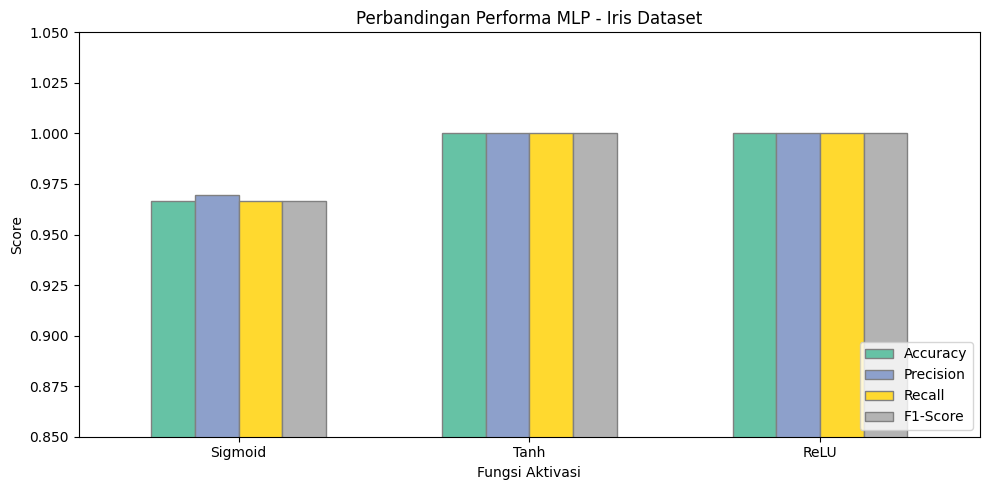

In [26]:
# plot bar chart buat bandingin
ax = df_hasil.plot(kind='bar', figsize=(10, 5), rot=0, colormap='Set2', edgecolor='gray', width=0.6)

plt.title('Perbandingan Performa MLP - Iris Dataset')
plt.xlabel('Fungsi Aktivasi')
plt.ylabel('Score')
plt.ylim(0.85, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('perbandingan_aktivasi.png', dpi=120)
plt.show()

## Confusion Matrix

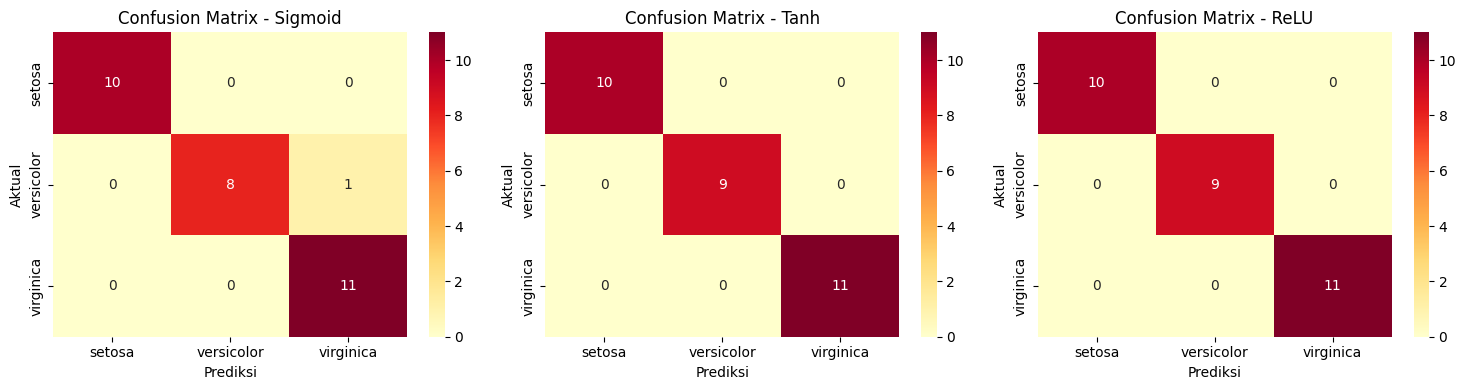

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

data_cm = [
    ('Sigmoid', pred_sigmoid),
    ('Tanh', pred_tanh),
    ('ReLU', pred_relu)
]

for ax, (nama, pred) in zip(axes, data_cm):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
                xticklabels=iris.target_names,
                yticklabels=iris.target_names)
    ax.set_title(f'Confusion Matrix - {nama}')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

In [28]:
# classification report detail
for nama, pred in data_cm:
    print(f'--- {nama} ---')
    print(classification_report(y_test, pred, target_names=iris.target_names))

--- Sigmoid ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30

--- Tanh ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

--- ReLU ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00

## Kesimpulan

Berdasarkan hasil percobaan di atas, ketiga fungsi aktivasi menghasilkan performa yang cukup tinggi pada dataset iris. Hal ini wajar karena iris merupakan dataset yang relatif sederhana dan mudah dipisahkan.

Dari tabel perbandingan:
- **Sigmoid** — bekerja cukup baik tapi cenderung lebih lambat converge karena output-nya terbatas di [0,1] dan rentan vanishing gradient
- **Tanh** — sedikit lebih baik dari sigmoid karena output-nya zero-centered di [-1,1] sehingga gradiennya lebih stabil
- **ReLU** — performa bagus dan paling cepat converge karena komputasinya simpel, gradiennya tidak menghilang untuk nilai positif

**Fungsi aktivasi terbaik untuk dataset iris adalah ReLU.**

Alasannya karena ReLU konvergen lebih cepat, tidak kena masalah vanishing gradient seperti sigmoid maupun tanh, dan secara keseluruhan memberikan performa yang stabil. Meskipun di dataset kecil seperti iris perbedaannya tidak terlalu jauh, ReLU tetap jadi pilihan yang paling efisien dan scalable kalau nanti dipakai di dataset yang lebih besar dan kompleks.